In [1]:
import sys
sys.path.append('../src')
from utils.stock_simulation import Stock
from utils.report import fast_config
from utils.simulation import save_session, load_session
from utils.simulation.session import save_markets, load_markets

Markets loaded ← /Users/edouardblanc/Desktop/cours_203_m2/S2/electronic_trading/projet_market_making/test/../src/utils/simulation/saved_markets.pkl


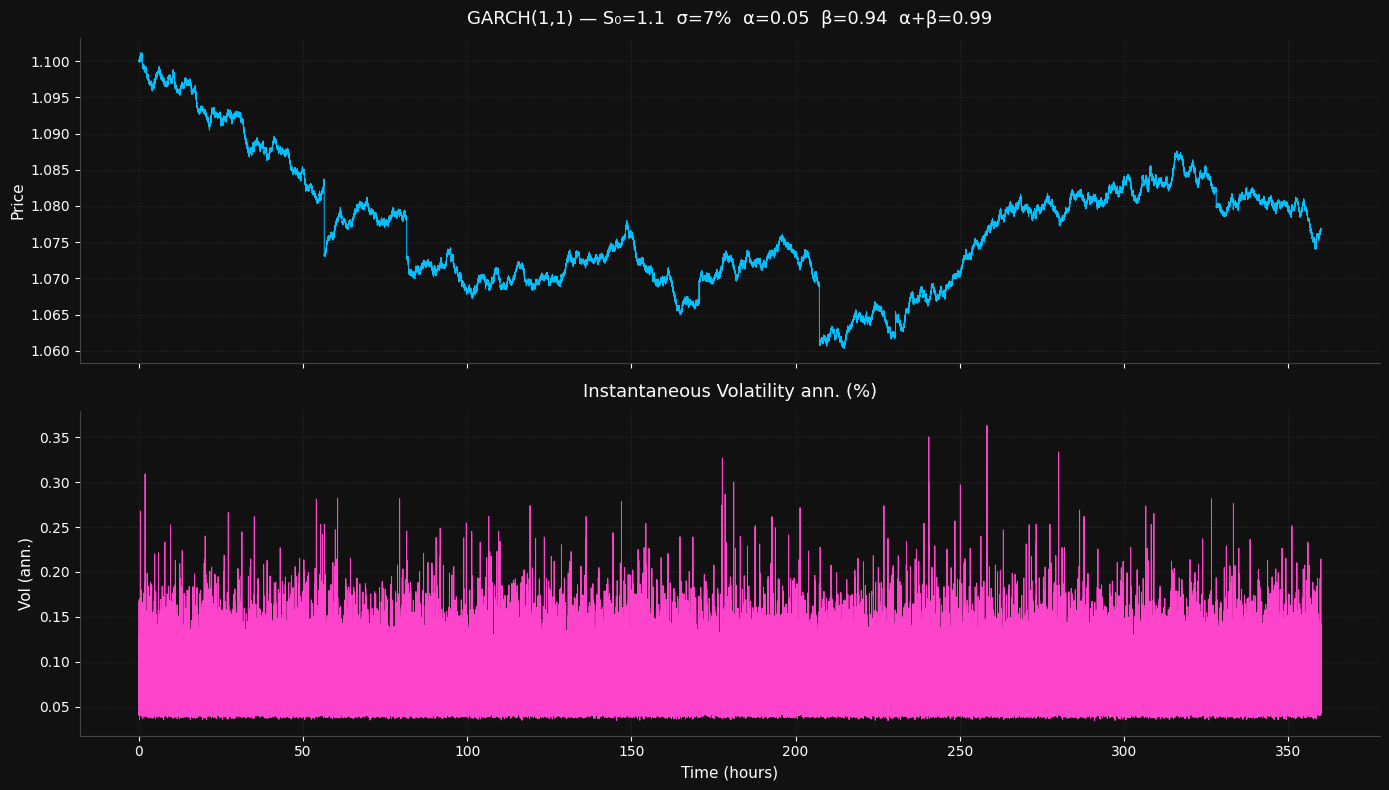

────────────────────────────────────────────────────────────────────────────
Metric                                               Skewed
────────────────────────────────────────────────────────────────────────────
Spread mean (price units)                            0.0002
Spread std  (price units)                            0.0000
Spread min  (price units)                            0.0002
Spread max  (price units)                            0.0002
Relative spread mean (%)                           0.0149%
Relative spread std  (%)                           0.0002%
Ask bias vs mid (mean)                               0.0001
Bid bias vs mid (mean)                               0.0001
Ask vol (ann., log-ret)                            9.0554%
Bid vol (ann., log-ret)                            9.0554%
Quote center offset (mean)                          -0.0000
Ask half − Bid half (mean)                          -0.0000
──────────────────────────────────────────────────────────────────────

In [2]:
# ── RUN ONCE to generate markets, then comment out ──────────────────────────
# Regenerate only when you want a new price path or spread shape.

# stock = Stock(drift=0.0, vol=0.07, origin=1.10)
# stock.simulate_garch(n_days=15, dt_seconds=0.05,
#                      alpha=0.05, beta=0.94,
#                      lam=100,       # 100 jumps/year ≈ 2/week  (was 300 = 1.2/day, too frequent)
#                      sigma_J=0.005) # ±0.5% per jump std ≈ 55 pips on EUR/USD
# market_B, market_C = fast_config.build_markets_B_C(stock)
# save_markets(stock, market_B, market_C)

# ── ALWAYS: load saved markets ───────────────────────────────────────────────
stock, market_B, market_C = load_markets()
stock.plot_vol_path()
#market_B.plot_noised_mid_price()
market_B.sanity_check_spreads()
#market_C.plot_noised_mid_price()
market_C.sanity_check_spreads()

In [3]:
# ── RUN EVERY TIME: rebuild MM + book + controller from current fast_config ──
# Changes to fast_config.py (gamma, delta_limit, ...) are picked up here.
market_maker, book = fast_config.build_market_maker_and_order_book(market_B, market_C)
controller = fast_config.build_controller(market_B, market_C, book, market_maker)

In [4]:
controller.simulate(limit = stock.n_steps//10)

100%|██████████| 2592000/2592000 [00:41<00:00, 62205.10it/s]


════════════════════════════════════════════════════════════════════
  BACKTESTING REPORT — Phase 1   (1.5 days, dt=0.1s, 2,592,000 steps)
════════════════════════════════════════════════════════════════════
  Total MtM P&L                              -887.65  USD
    Realized cash P&L                     -138676.39  USD
    Unrealized (open inventory × mid)      +137788.74  USD
────────────────────────────────────────────────────────────────────
  Inception spread P&L                       +585.45  USD
    (spread captured at fill time)  
  Inventory revaluation P&L                 -1308.32  USD
    (mid drift on open EUR position)
  Total fees paid                             164.78  USD
    Maker fees (exchange A)                   164.78  USD
    Taker fees (hedge B/C)                      0.00  USD
────────────────────────────────────────────────────────────────────
  MM fills                                       539  (359/day)
  Hedge legs                                       

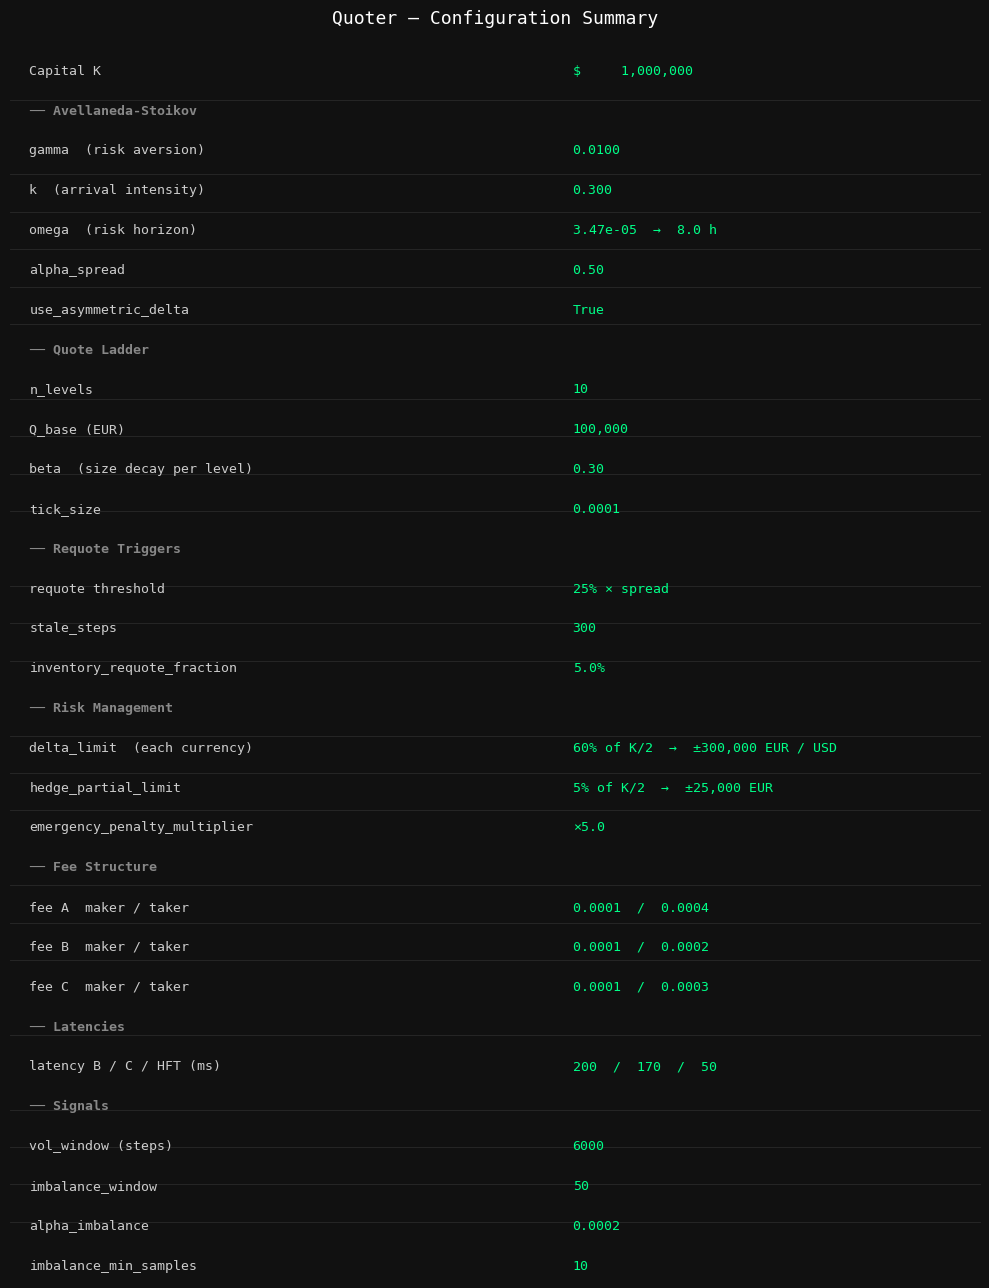

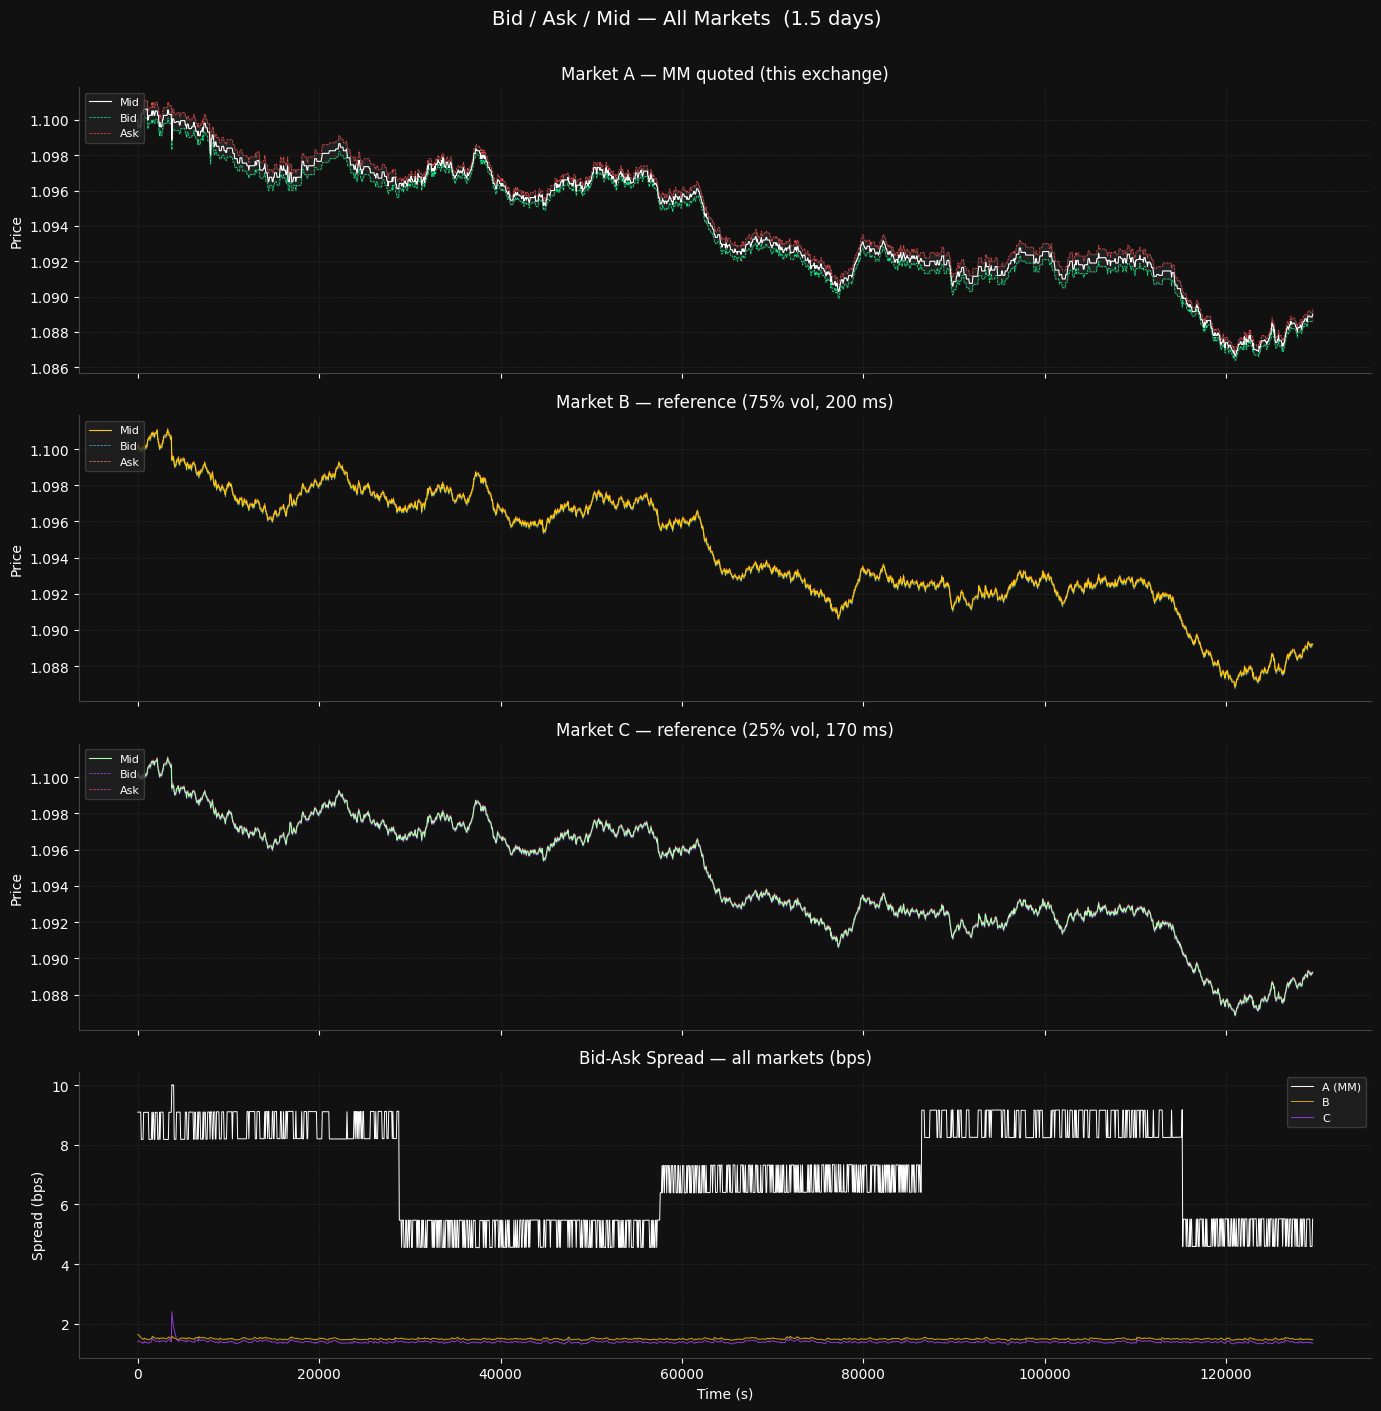

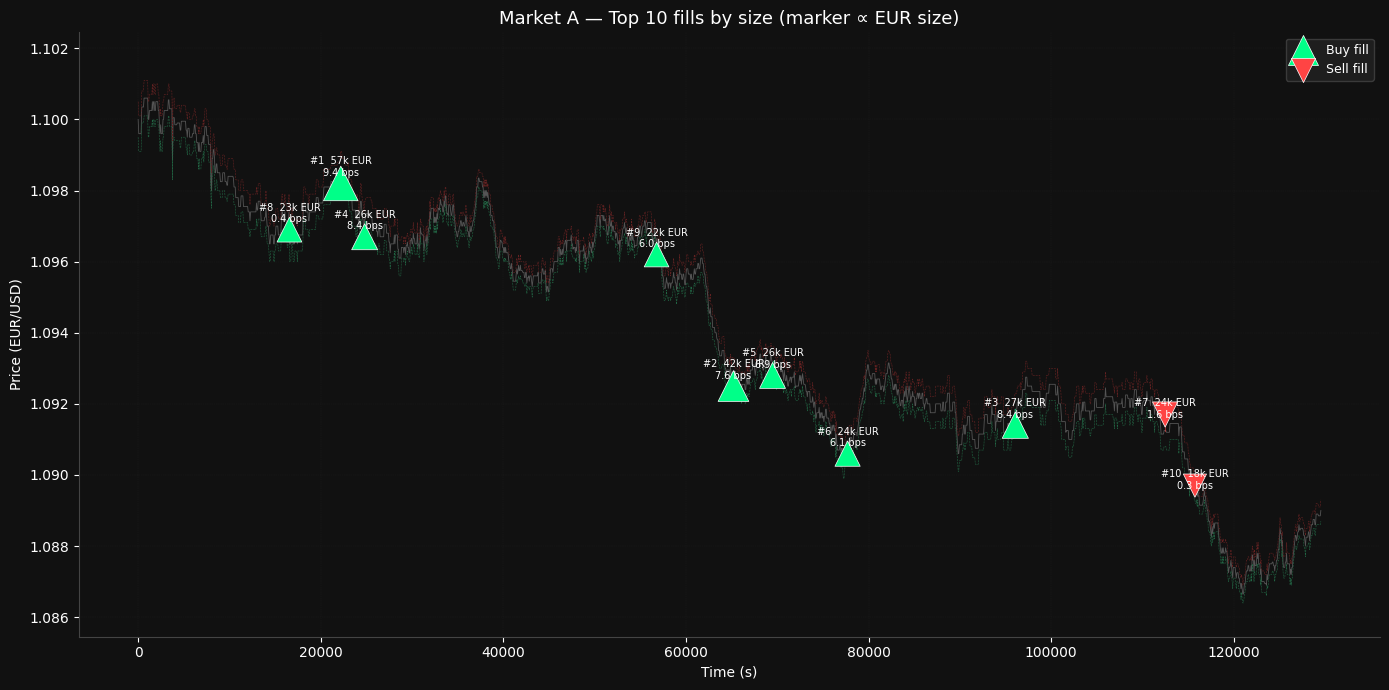

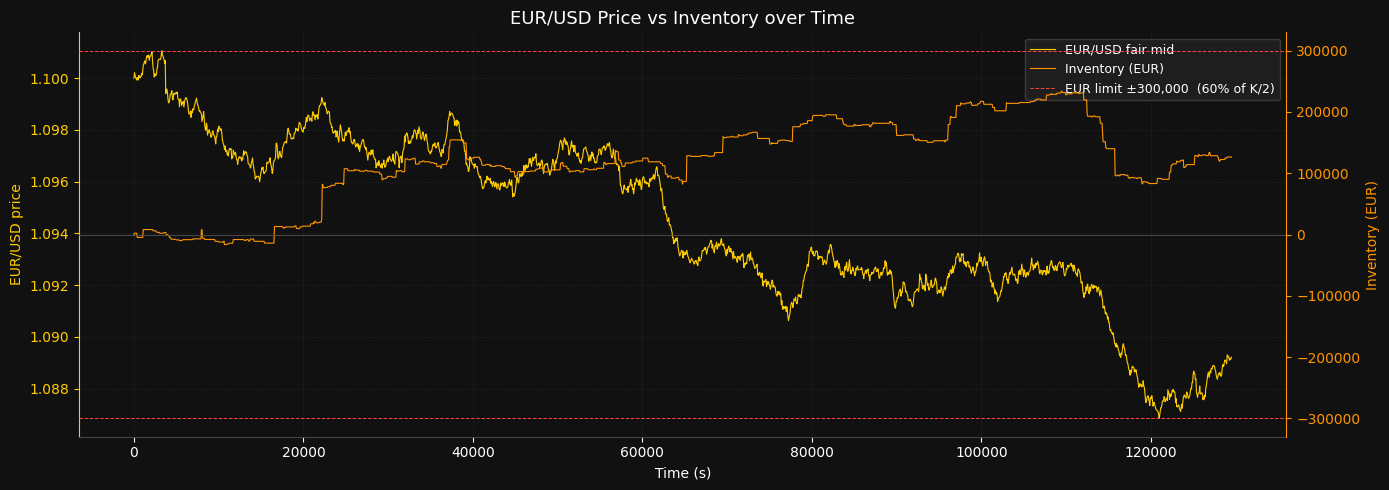

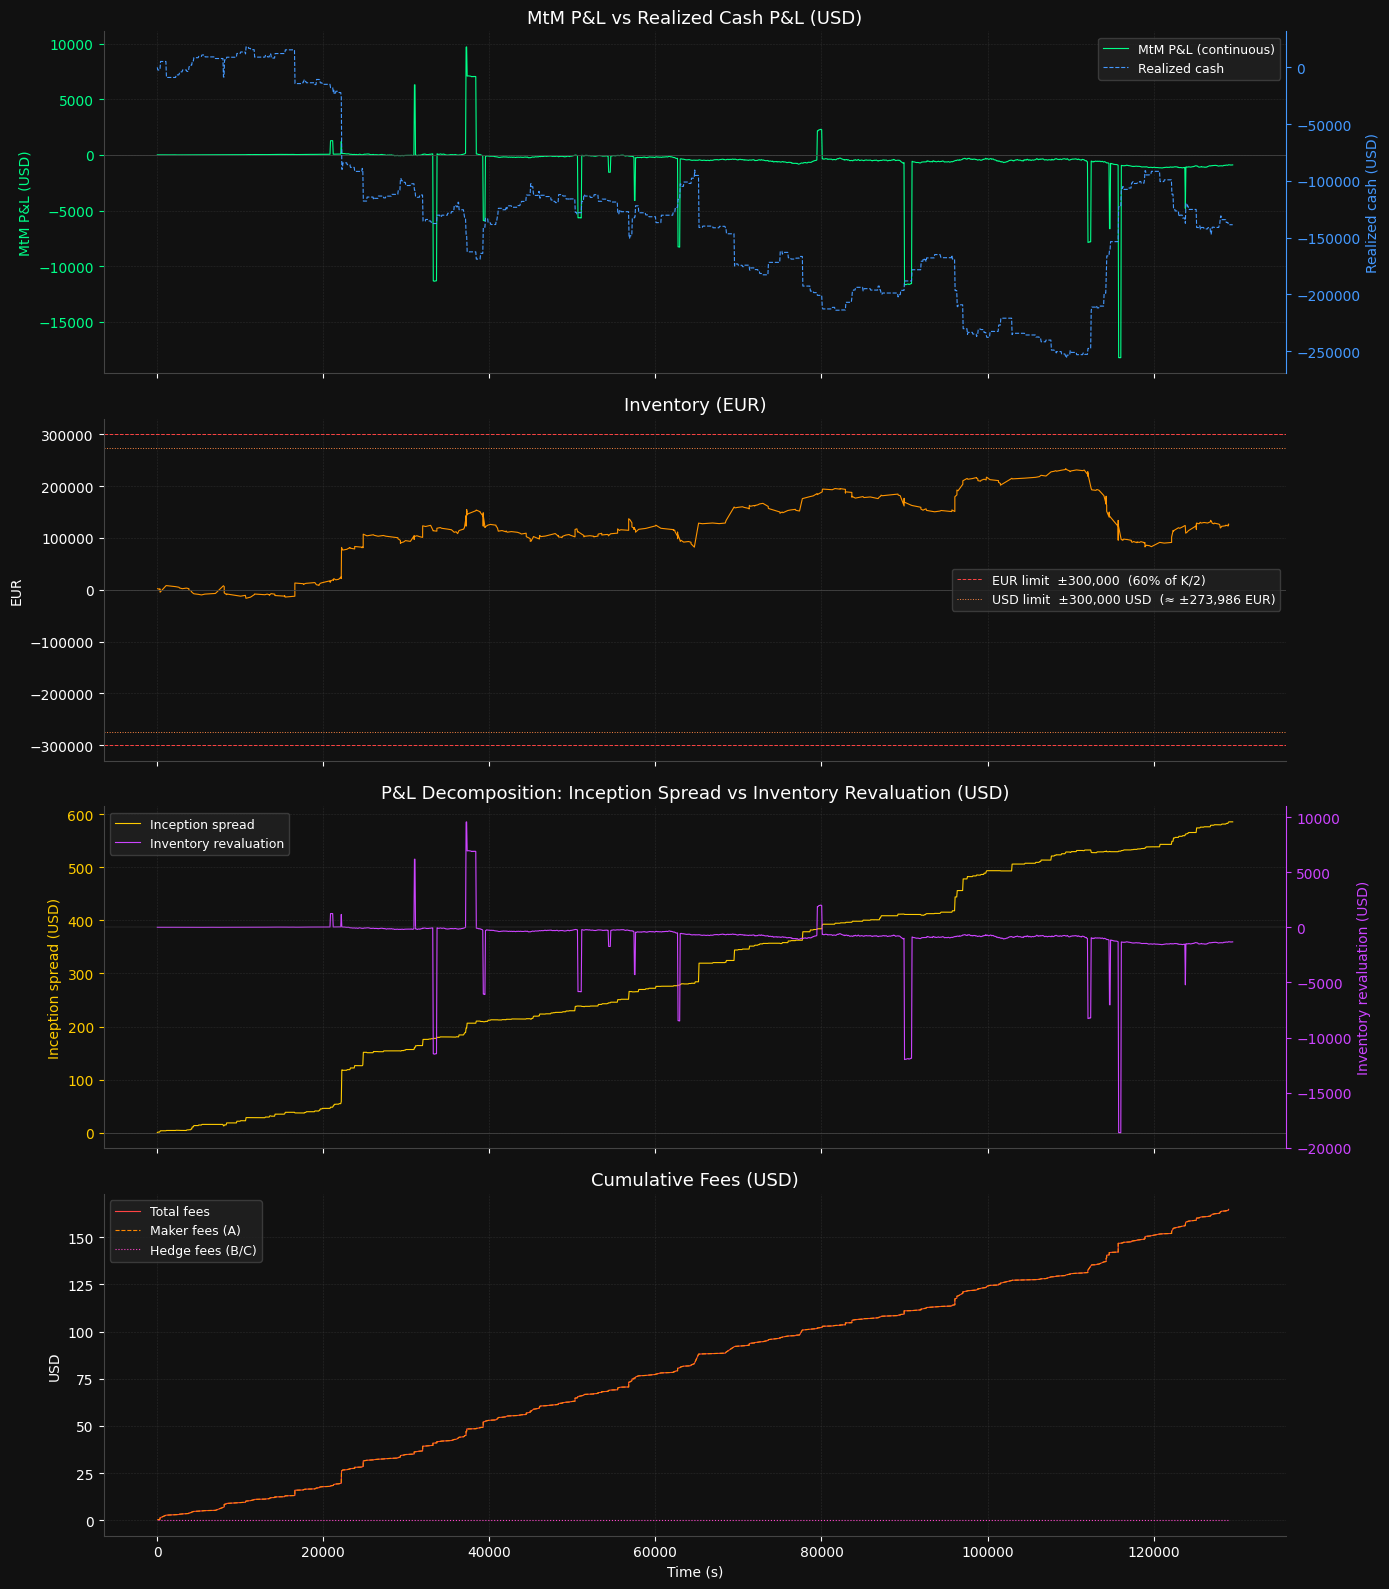

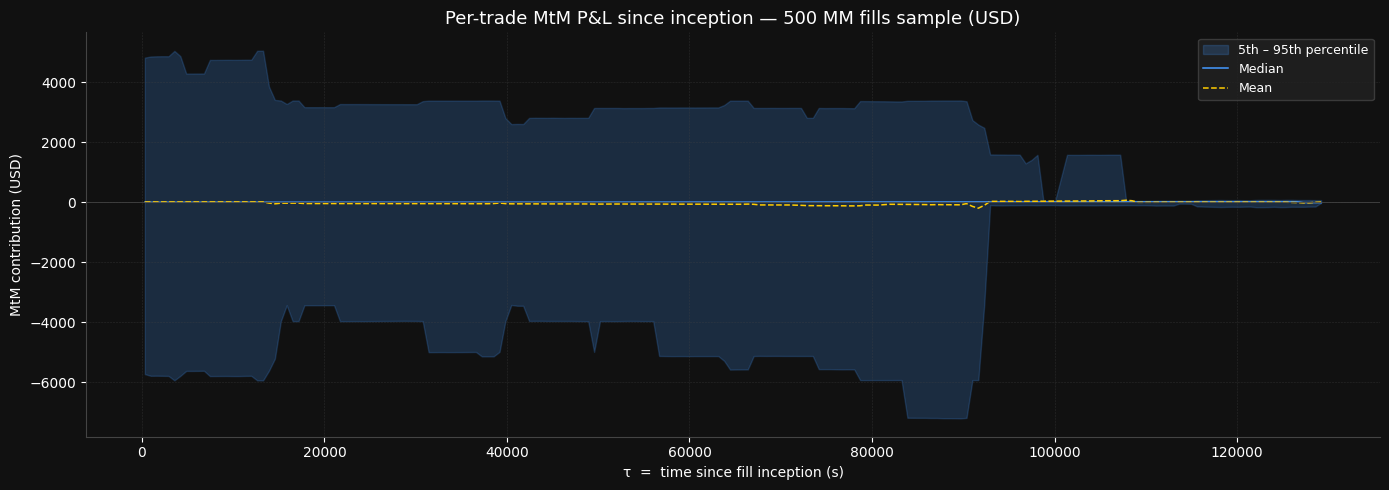

────────────────────────────────────────────────────────────────────
  FILL-RATE ANALYSIS
────────────────────────────────────────────────────────────────────
  MM fills                                       539
  Quotes posted                               29,774
  Overall fill rate                          1.8103%
  Avg fill size (EUR)                          2,794
  Full fills                                    0.0%
  Partial fills                               100.0%
────────────────────────────────────────────────────────────────────
  Level         Fill count   Relative rate
  1                    539           1.000
════════════════════════════════════════════════════════════════════


In [5]:
controller.report()

In [ ]:
controller.plot_market_quotes()

In [ ]:
controller.plot_top_trades()

In [ ]:
controller.plot_price_inventory()

In [ ]:
controller.plot_mtm_percentiles()